In [1]:
from pathlib import Path

import geopandas as gpd
import osmnx as ox

ox.__version__

'2.1.0'

In [2]:
bounding_box = [-73.62368, 45.44845, -73.43142, 45.53822]
G = ox.graph.graph_from_bbox(bounding_box, network_type="bike")

In [3]:
print(type(G))
print(G)

<class 'networkx.classes.multidigraph.MultiDiGraph'>
MultiDiGraph with 28847 nodes and 72094 edges


In [4]:
#nearest node
#node = ox.distance.nearest_nodes(Gp, X0, Y0)

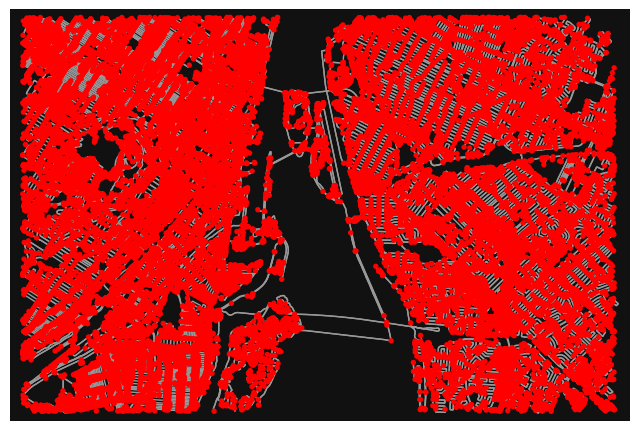

/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_98500/4005865508.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [5]:
fig, ax = ox.plot.plot_graph(G, node_color="r")
fig.show()

74 bicycle rental locations found


/var/folders/zl/szf1xwds0z98zzqy12bp4q_00000gn/T/ipykernel_98500/4193336117.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


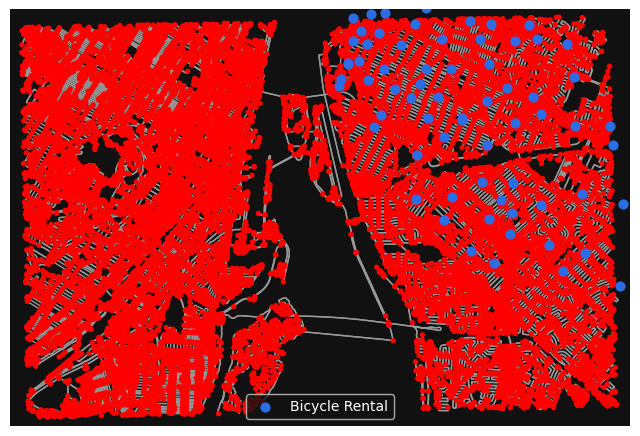

In [7]:
bike_rentals = ox.features.features_from_place(
    "Longueuil, Quebec, Canada",
    tags={"amenity": "bicycle_rental"},
)
print(f"{len(bike_rentals)} bicycle rental locations found")

G_proj = ox.projection.project_graph(G)
nodes_gdf, _ = ox.convert.graph_to_gdfs(G_proj)
bike_rentals_proj = bike_rentals.to_crs(nodes_gdf.crs)
centroids = bike_rentals_proj.geometry.centroid

fig, ax = ox.plot.plot_graph(G_proj, node_color="r", show=False, close=False)
ax.scatter(centroids.x, centroids.y, c="#2a6ee6", s=40, zorder=5, label="Bicycle Rental")
ax.legend(facecolor="#111111", labelcolor="white")
fig.show()

In [ ]:
import json
import geopandas as gpd
from shapely.geometry import Point

DATA_PATH = "/Volumes/Extreme SSD/SUMO Data/station_information.json"
min_lon, min_lat, max_lon, max_lat = bounding_box  # [-73.62368, 45.44845, -73.43142, 45.53822]

with open(DATA_PATH) as f:
    raw = json.load(f)

bbox_stations = [
    s for s in raw["data"]["stations"]
    if s["lat"] != 0 and s["lon"] != 0
    and min_lon <= s["lon"] <= max_lon
    and min_lat <= s["lat"] <= max_lat
]
print(f"{len(bbox_stations)} stations inside bounding box")

# Build a projected GeoDataFrame matching the graph CRS
G_proj = ox.projection.project_graph(G)
nodes_gdf, _ = ox.convert.graph_to_gdfs(G_proj)

stations_gdf = gpd.GeoDataFrame(
    bbox_stations,
    geometry=[Point(s["lon"], s["lat"]) for s in bbox_stations],
    crs="EPSG:4326",
).to_crs(nodes_gdf.crs)

fig, ax = ox.plot.plot_graph(G_proj, node_color="#444444", node_size=2,
                              edge_color="#888888", edge_linewidth=0.5,
                              show=False, close=False)

ax.scatter(
    stations_gdf.geometry.x,
    stations_gdf.geometry.y,
    c="#e63e2a", s=50, zorder=5, label="BIXI Station",
)

for _, row in stations_gdf.iterrows():
    ax.annotate(
        row["name"], xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4), textcoords="offset points",
        fontsize=4, color="white", zorder=6,
    )

ax.legend(facecolor="#111111", labelcolor="white")
fig.show()